# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() #cuda 없으니까 코드가 너무 오래 걸려서 mps로 해보겠습니다
    else "cpu"
)

print("사용 디바이스:", device)


사용 디바이스: mps


### **데이터셋 준비 (MNIST dataset)**

In [16]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [17]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* encode는 입력을 fc1과 ReLU로 변환한 뒤 fc21과 fc22를 각각 적용하여 분포룰 구하고, reparameterize는 std = exp(0.5 × logvar)로 표준편차를 구하고, 표준정규분포에서 뽑은 eps로 z = mu + std × eps를 만든다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [18]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 우선 데이터를 (B, 784)로 펼치고 recon_x를 예측값, x를 정답으로 하여 픽셀별로 BCE를 계산하고, KLD는 대각 정규분포 q(z|x)와 표준정규분포 사이의 거리를 의미한다. 마지막으로 샘플당 평균 손실을 얻고 더한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* BCE만 줄이면 encoder가 데이터를 서로 떨어진 잠재 영역에 배치하여 임의의 z에서 좋은 이미지를 생성하기 어려울 수 있다. 여기서 KLD가 필요한데 KLD는 q(z|x)가 사전분포에서 지나치게 벗어나지 않게 정규화하여 학습 때의 잠재 분포와 생성 때 샘플링하는 분포의 차이를 줄이고 연속적인 잠재 표현을 유도하게끔 해준다.


In [19]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3082 | Val Loss: 1.0283
Epoch [2/15] Train Loss: 0.9620 | Val Loss: 0.9292
Epoch [3/15] Train Loss: 0.9021 | Val Loss: 0.8938
Epoch [4/15] Train Loss: 0.8762 | Val Loss: 0.8750
Epoch [5/15] Train Loss: 0.8622 | Val Loss: 0.8632
Epoch [6/15] Train Loss: 0.8523 | Val Loss: 0.8579
Epoch [7/15] Train Loss: 0.8454 | Val Loss: 0.8515
Epoch [8/15] Train Loss: 0.8401 | Val Loss: 0.8461
Epoch [9/15] Train Loss: 0.8357 | Val Loss: 0.8433
Epoch [10/15] Train Loss: 0.8320 | Val Loss: 0.8389
Epoch [11/15] Train Loss: 0.8292 | Val Loss: 0.8353
Epoch [12/15] Train Loss: 0.8267 | Val Loss: 0.8350
Epoch [13/15] Train Loss: 0.8242 | Val Loss: 0.8342
Epoch [14/15] Train Loss: 0.8224 | Val Loss: 0.8313
Epoch [15/15] Train Loss: 0.8203 | Val Loss: 0.8290


**VAE sampling 시각화**

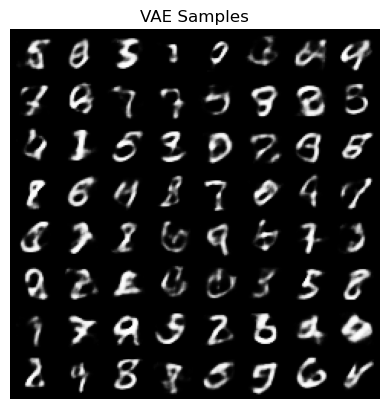

In [20]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [22]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [23]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 입력 z의 크기를 합성곱을 통해 공간 크기를 1→7→14→28로 늘리고 각 중간 단계에 BatchNorm과 ReLU를 적용한다. 마지막 self.tconv4(x)는 1채널 이미지를 만들고 tanh는 픽셀 범위를 [-1, 1]로 제한한다. 이러한 과정을 통해 정규화된 MNIST와 같은 크기와 범위의 이미지를 생성한다. 


In [24]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 이미지를 합성곱으로 28→14→7→3→1 크기로 줄이면서 진짜와 가짜를 구분할 특징을 추출하고, 합성곱과 sigmoid는 이미지별 진짜일 확률을 출력하고 view와 squeeze로 (B,) 형태를 만든다. 


In [25]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [26]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7927 | Loss G: 1.7198
Epoch [2/15] Loss D: 0.8795 | Loss G: 1.4683
Epoch [3/15] Loss D: 0.9446 | Loss G: 1.4043
Epoch [4/15] Loss D: 0.9905 | Loss G: 1.3367
Epoch [5/15] Loss D: 0.9933 | Loss G: 1.3584
Epoch [6/15] Loss D: 0.9787 | Loss G: 1.3812
Epoch [7/15] Loss D: 0.9803 | Loss G: 1.4065
Epoch [8/15] Loss D: 0.9461 | Loss G: 1.4524
Epoch [9/15] Loss D: 0.9507 | Loss G: 1.4696
Epoch [10/15] Loss D: 0.9398 | Loss G: 1.4736
Epoch [11/15] Loss D: 0.9247 | Loss G: 1.5211
Epoch [12/15] Loss D: 0.9193 | Loss G: 1.5250
Epoch [13/15] Loss D: 0.9271 | Loss G: 1.5368
Epoch [14/15] Loss D: 0.8838 | Loss G: 1.5984
Epoch [15/15] Loss D: 0.8662 | Loss G: 1.6296


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 생성자는 가짜 이미지가 진짜로 판별되기를 원하므로 BCE의 목표값으로 1로 채운 real을 사용한다. 그러면서 D(fake_img)에 detach를 적용하지 않아 판별자를 통과한 기울기가 생성자까지 전달되며 optG.step()이 생성자 가중치를 갱신한다. 반대로 판별자 학습에서는 fake_img.detach()로 생성자와의 계산 그래프를 멈춘다. 


**DCGAN Sampling 시각화**

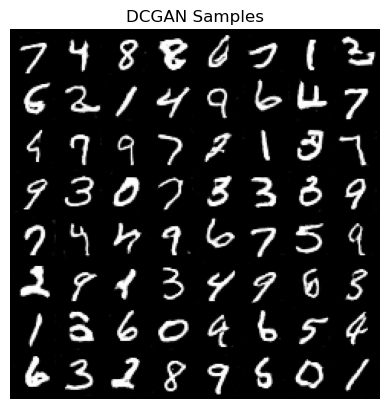

In [27]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 픽셀별 복원 오차와 KL 정규화를 함께 최소화하는데 잠재 압축으로 세부 정보가 손실되고 여러 복원이 가능한 경우 픽셀별 확률의 평균적인 출력이 나타나 경계가 흐려질 수 있다. 이와 달리 GAN은 특정 원본과의 픽셀 일치보다 판별자가 진짜로 판단할 질감과 경계를 학습하므로 이미지가 선명해질 수 있다. 


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* 판별자가 너무 빨리 강해져 실제와 생성 분포를 완전히 분리하면 생성자는 좋은 개선 방향을 알기 어려워진다. 특히 생성자 목적함수에서 sigmoid가 포화된다면 vanishing gradient가 심해질 수 있으며, 반대로 생성자가 약한 판별자를 이용해버리면 잘 속이는 패턴만을 반복하는 mode collapse가 발생할 수 있다. 


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [29]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 각 이미지의 t로 sqrt(a)와 sqrt(1-a)를 조회하고 (B, 1, 1, 1)로 바꾼 후, 원본과 노이즈를 각각 해당 계수로 곱해 더하면 중간 단계를 반복하지 않고 x_t를 직접 얻는다. 실제 주입한 noise도 반환하여 학습 정답으로 사용한다. 


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

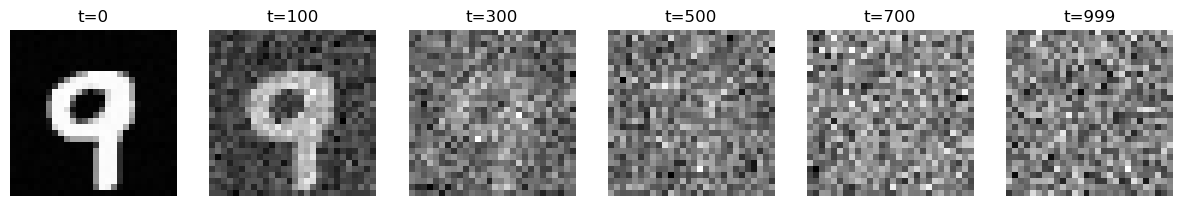

In [30]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [31]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 같은 이미지라도 timestep에 따라 제거해야 할 노이즈가 다를 것이므로 시간 정보를 넣어주는 코드이며 bottleneck은 이미지 특징과 현재 노이즈 단계를 함께 이용한다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [32]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 배치의 각 이미지에 0~T-1 중 timestep을 랜덤으로 뽑고 forward_diffusion으로 noisy image와 실제 노이즈를 생성하고, model(x_t, t)가 예측한 노이즈와 실제 noise의 원소별 제곱 오차를 F.mse_loss로 평균을 구한다.


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* Timestep마다 같은 기준의 분포를 사용하므로 단순한 MSE 회귀 문제로 학습할 수 있어지기 때문이다. 또한 노이즈 예측은 score 추정과 연결되어 역방향 업데이트에도 활용이 가능하다.


In [33]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [36]:
# !pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict([('num_train_timesteps', 1000), ('beta_start', 0.0001), ('beta_end', 0.02), ('beta_schedule', 'squaredcos_cap_v2'), ('trained_betas', None), ('variance_type', 'fixed_small'), ('clip_sample', True), ('prediction_type', 'epsilon'), ('thresholding', False), ('dynamic_thresholding_ratio', 0.995), ('clip_sample_range', 1.0), ('sample_max_value', 1.0), ('timestep_spacing', 'leading'), ('steps_offset', 0), ('rescale_betas_zero_snr', False), ('_class_name', 'DDPMScheduler'), ('_diffusers_version', '0.27.2')])


  0%|          | 0/200 [00:00<?, ?it/s]

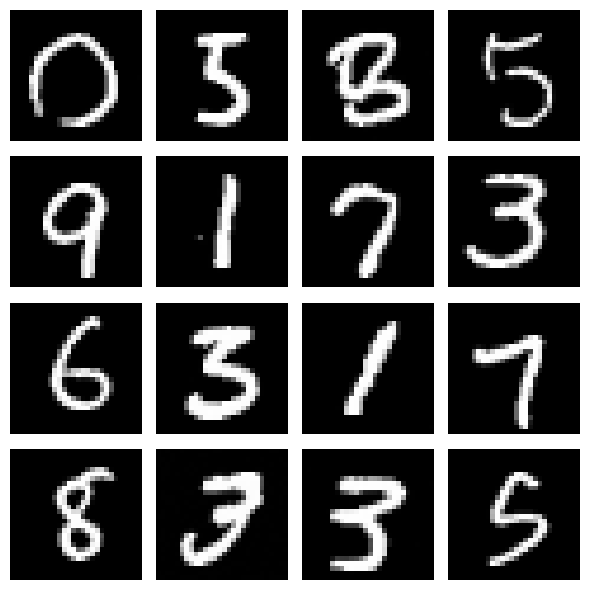

In [35]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- Mnist에는 다양한 필기체가 있으나 모델은 특정 숫자나 필기체를 지정받지 않은 채 무작위 노이즈에서 샘플링한다. 결국 추론 step 수와 seed와 같은 것이 결과에 영향을 준다. 일관적인 결과를 보고 싶다면 같은 seed에서 전체 step 수와 200 step을 비교해보고 여러 seed로도 반복을 해봐야 한다. 

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...



## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [ ]:
# !pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [39]:
# cuda로 하니까 출력이 안돼 LLM 활용해서 수정했습니다
import torch
from diffusers import StableDiffusionPipeline

model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# Mac GPU를 사용할 수 있으면 MPS, 아니면 CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    dtype = torch.float16

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
        variant="fp16",
        use_safetensors=True
    )
else:
    device = torch.device("cpu")
    dtype = torch.float32

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
        use_safetensors=True
    )

pipe = pipe.to(device)

# Mac의 메모리 사용량 감소
pipe.enable_attention_slicing()

print("사용 디바이스:", device)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

사용 디바이스: mps


  0%|          | 0/30 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


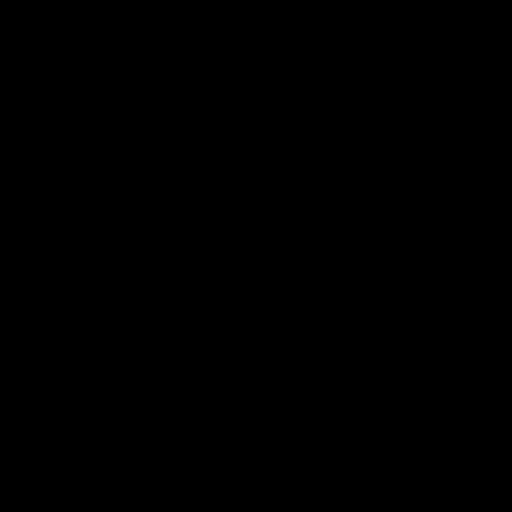

In [ ]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"    # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image 


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* num_inference_steps=30은 노이즈 제거를 30번의 스케줄러 단계로 진행하도록 지정한다. step이 너무 적으면 코드가 빠르게 돌아가기는 하겠지만 디테일한 측면에서 다소 아쉬울 수 있고, 늘리면 계산 시간이 증가하지만 결과가 개선될 수 있다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* CFG는 ε_CFG = ε_uncond + s(ε_cond - ε_uncond)로 조건 방향을 강화한다. s=1.0이면 식상 조건부 예측 자체가 되어 추가적인 증폭이 없고 s=15.0이면 프롬프트 특징을 더 강하게 반영할 것임을 알 수 있다. 그러나 과도하게 높은 값은 왜곡을 유발할 수 있다.


  0%|          | 0/30 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.11/site-packages/diffusers/image_processor.py:142: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/30 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


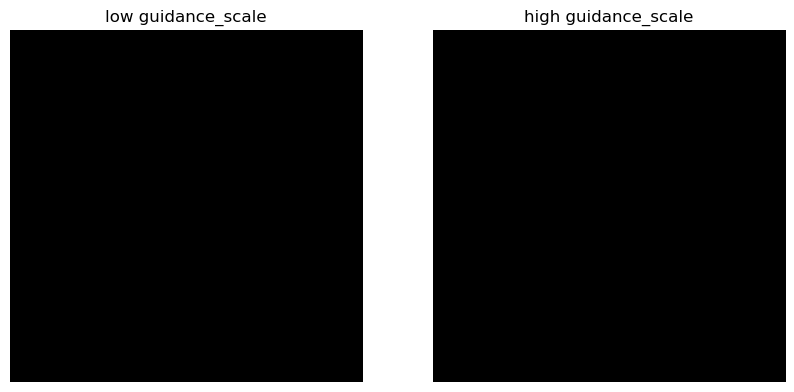

In [47]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* guidance_scale에 1.0과 15.0을 대입을 하게 되면 두 호출에 같은 seed로 새로 만든 generator를 전달하므로 CFG 효과를 비교할 수 있다. 


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


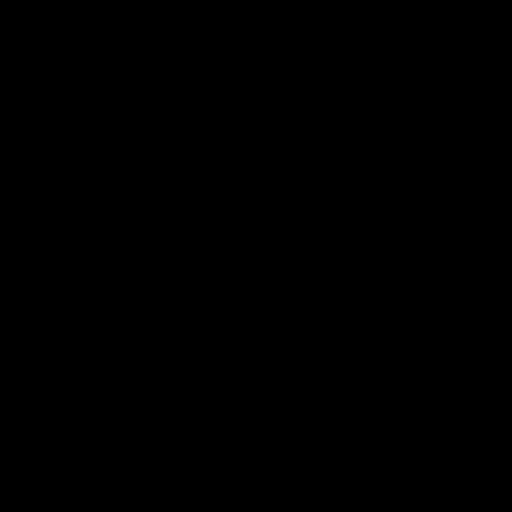

In [48]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* DDPM의 reverse process는 연속된 단계에서 조건부 분포를 따라 노이즈를 제거해가며 확률적 노이즈를 다시 더한다. 반면 DDIM은 동일한 학습 목적과 노이즈 예측 모델을 활용하면서 비마르코프 순방향 과정에 대응하는 샘플링 경로를 구성한다. 일부 timestep만 선택하고 예측한 x0와 노이즈 방향으로 다음 시점으로 이동할 수 있어 매 단계를 모두 거치지 않아도 된다는 특징을 지닌다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)


수고하셨습니다 ☺️